In [7]:
import numpy as np
import networkx as nx
from grakel import GraphKernel
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.utils import to_networkx

In [8]:
import networkx as nx
from torch_geometric.datasets import TUDataset

# Specify the name of the dataset you want to load
dataset_name = 'ENZYMES'  # Example dataset name

# Load the dataset
dataset = TUDataset(root='data/TUDataset', name=dataset_name)

# Get the first graph from the dataset
data = dataset[0]

# Convert PyG data to NetworkX graph
G1 = nx.Graph()
G1.add_edges_from(data.edge_index.T.numpy())

# Compute edge weights (e.g., using edge betweenness centrality)
edge_weights = nx.edge_betweenness_centrality(G1)

# Print edge weights
print("Edge weights:")
for edge, weight in edge_weights.items():
    print(f"Edge {edge}: weight = {weight}")


Processing...


Edge weights:
Edge (0, 1): weight = 0.010522427189093846
Edge (0, 2): weight = 0.015193765193765188
Edge (0, 3): weight = 0.028337861671194984
Edge (1, 2): weight = 0.0030655655655655654
Edge (1, 3): weight = 0.014326826826826828
Edge (1, 24): weight = 0.024593045426378753
Edge (1, 27): weight = 0.02309154392487725
Edge (2, 3): weight = 0.01051051051051051
Edge (2, 27): weight = 0.01689785023118355
Edge (2, 28): weight = 0.03889901806568468
Edge (3, 4): weight = 0.0233417941751275
Edge (3, 5): weight = 0.04229825063158401
Edge (3, 28): weight = 0.03620882787549452
Edge (24, 27): weight = 0.002002002002002002
Edge (24, 28): weight = 0.006819319319319318
Edge (24, 29): weight = 0.06131726965060302
Edge (27, 28): weight = 0.006068568568568568
Edge (27, 29): weight = 0.07496186662853331
Edge (28, 26): weight = 0.06940273606940275
Edge (28, 29): weight = 0.043993398160064846
Edge (4, 5): weight = 0.003503503503503503
Edge (4, 6): weight = 0.030405405405405404
Edge (4, 29): weight = 0.068637

Done!


In [9]:

# Get the first graph from the dataset
data2 = dataset[1]

# Convert PyG data to NetworkX graph
G2 = nx.Graph()
G2.add_edges_from(data2.edge_index.T.numpy())

# Compute edge weights (e.g., using edge betweenness centrality)
edge_weights2 = nx.edge_betweenness_centrality(G2)



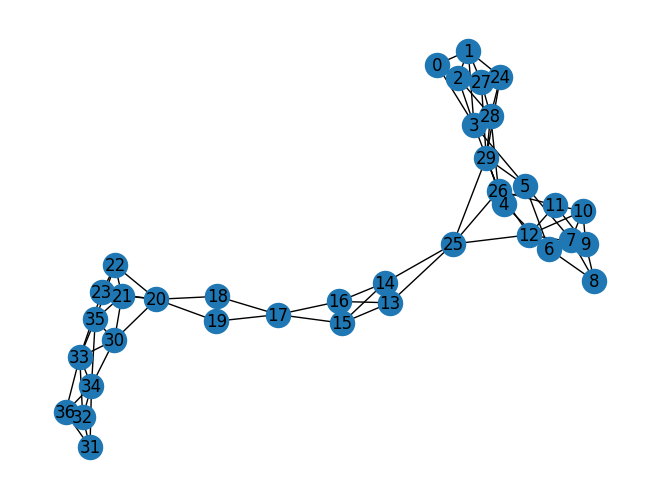

In [10]:
nx.draw(G1, with_labels = True)
plt.show()

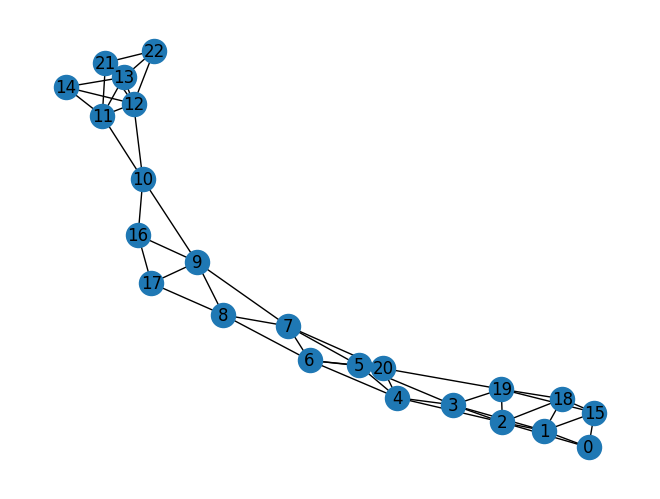

In [11]:
nx.draw(G2, with_labels = True)
plt.show()

In [12]:
import networkx as nx
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def compute_node_embeddings(graph, commute_time):
    """
    Compute node embeddings for a graph using commute time as edge weights.

    Parameters:
        graph (networkx.Graph): Input graph.
        commute_time (numpy.ndarray): Commute time matrix representing edge weights.

    Returns:
        numpy.ndarray: Node embeddings for the graph.
    """
    num_nodes = len(graph.nodes)
    node_embeddings = np.zeros((num_nodes, num_nodes))  # Initialize node embeddings matrix

    # Iterate over nodes and compute shortest paths using commute time as edge weights
    for node in graph.nodes:
        shortest_paths = nx.single_source_dijkstra_path_length(graph, node, weight='weight')
        for target, distance in shortest_paths.items():
            node_embeddings[node][target] = 1.0 / (1.0 + distance)  # Weighted distance-based aggregation

    return node_embeddings

def cosine_similarity_kernel(graph1, graph2, commute_time):
    """
    Compute the cosine similarity kernel between two graphs using commute time as edge weights.

    Parameters:
        graph1 (networkx.Graph): First input graph.
        graph2 (networkx.Graph): Second input graph.
        commute_time (numpy.ndarray): Commute time matrix representing edge weights.

    Returns:
        numpy.ndarray: Cosine similarity kernel between the graphs.
    """
    # Compute node embeddings for each graph using commute time as edge weights
    embeddings1 = compute_node_embeddings(graph1, commute_time)
    embeddings2 = compute_node_embeddings(graph2, commute_time)

    # Pad the matrices to match the maximum number of nodes between the two graphs
    max_nodes = max(embeddings1.shape[0], embeddings2.shape[0])
    embeddings1_padded = np.pad(embeddings1, ((0, max_nodes - embeddings1.shape[0]), (0, max_nodes - embeddings1.shape[1])), mode='constant')
    embeddings2_padded = np.pad(embeddings2, ((0, max_nodes - embeddings2.shape[0]), (0, max_nodes - embeddings2.shape[1])), mode='constant')

    # Compute cosine similarity kernel
    kernel = cosine_similarity(embeddings1_padded, embeddings2_padded)

    return kernel


In [13]:
def compute_commute_times(graph):
    """Computes all-pairs commute times using Floyd-Warshall algorithm."""
    distances = nx.floyd_warshall_numpy(graph)  # Uses NumPy for efficiency
    commute_times = (distances + distances.T) / 2  # Average distances for both directions
    return commute_times

In [14]:
commute_time1 = compute_commute_times(G1)

In [15]:
kernel_commute_times = cosine_similarity_kernel(G1, G2, commute_time1)

Each point on the surface represents the commute time between two specific locations. The x-axis and y-axis correspond to the starting and ending points of the commute, respectively, while the z-axis represents the commute time itself.
Peaks and valleys on the surface indicate areas of high and low commute times, respectively. These could correspond to bottlenecks or congestion points in our network.
Slopes and gradients on the surface show how commute times change as we move between different locations. This can help us identify corridors where travel times are particularly efficient or inefficient.
Patterns or irregularities in the surface may suggest areas where improvements to our transportation infrastructure could be made to optimize commute times and enhance overall efficiency.

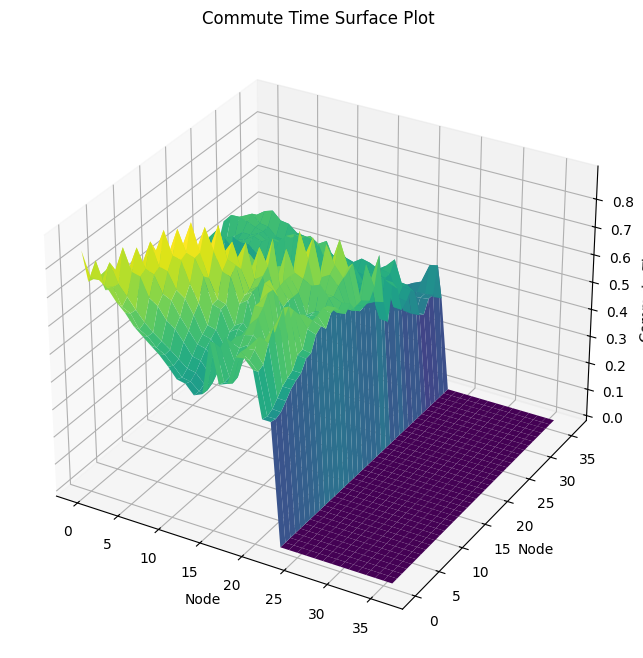

In [16]:

# Plot 3D surface of commute time matrix
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
x, y = np.meshgrid(np.arange(kernel_commute_times.shape[0]), np.arange(kernel_commute_times.shape[1]))
ax.plot_surface(x, y, kernel_commute_times, cmap='viridis')
ax.set_title('Commute Time Surface Plot')
ax.set_xlabel('Node')
ax.set_ylabel('Node')
ax.set_zlabel('Commute Time')
plt.show()

This graph shows us the commute times between nodes by displaying them in red along the edges.

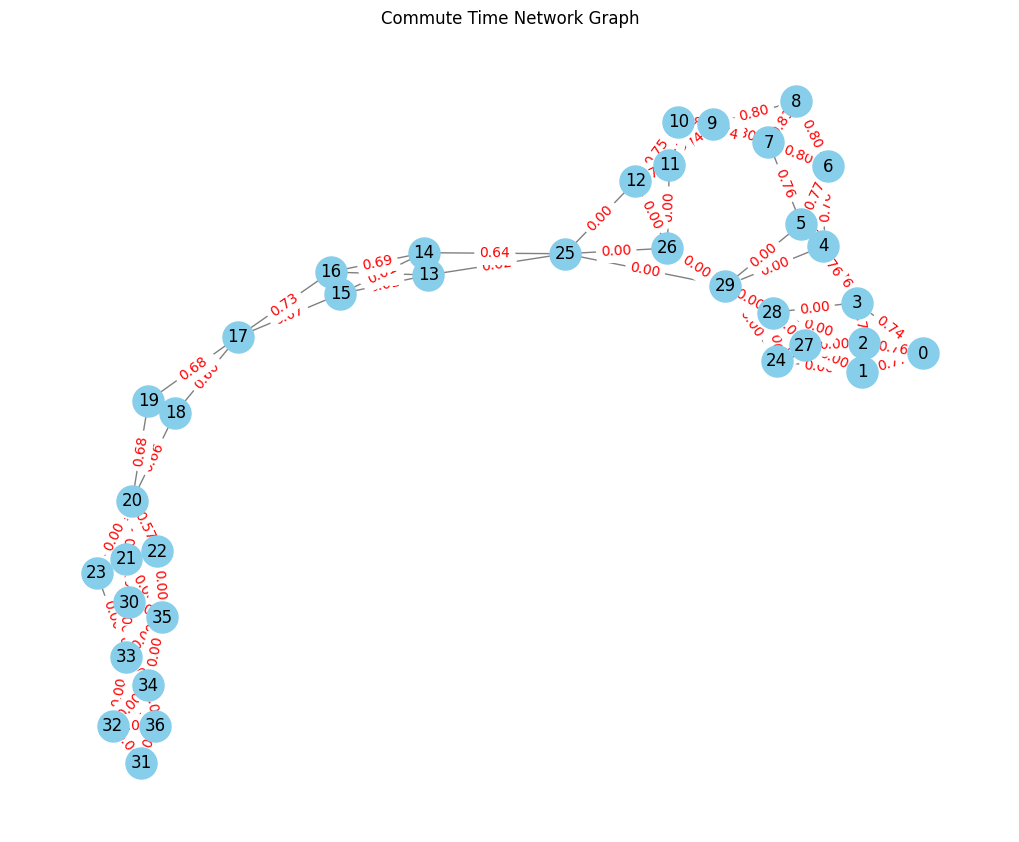

In [17]:
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G1)
edge_labels = {(i, j): f"{kernel_commute_times[i][j]:.2f}" for i, j in G1.edges()}
nx.draw(G1, pos, with_labels=True, node_size=500, node_color='skyblue', edge_color='gray')
nx.draw_networkx_edge_labels(G1, pos, edge_labels=edge_labels, font_color='red')
plt.title('Commute Time Network Graph')
plt.show()

the histogram provides us with a clear and concise summary of our commute time data, allowing us to quickly grasp the overall distribution and identify any notable features or trends.
By looking at the histogram, we can quickly see which commute times are most common and how they are distributed across different intervals. We can also identify any patterns, such as peaks or clusters, that may indicate specific trends or characteristics of our commute time data.

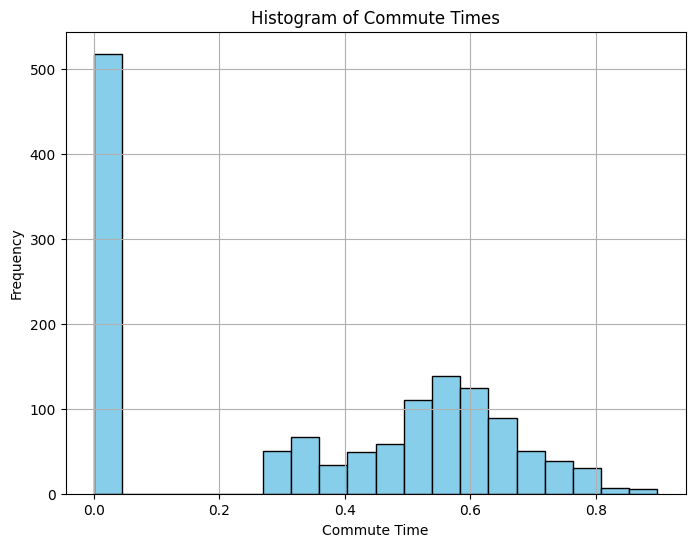

In [18]:
plt.figure(figsize=(8, 6))
plt.hist(kernel_commute_times.flatten(), bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Commute Times')
plt.xlabel('Commute Time')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()